# 02. Source model selection

This supporting notebook traces the VIS model-selection tree on a 50-arcsec
field. [Notebook 01](../01_multiband_forced_photometry.ipynb) uses the same
selector for its multi-band fit.

The implementation adapts [The Farmer](https://arxiv.org/abs/2310.07757).
It compares point-source, fixed circular exponential, exponential,
de Vaucouleurs, and composite profiles. A sufficient point-source fit can
stop early; the remaining candidates are compared using reduced chi-squared.
Bright resolved candidates can also try a free-index Sérsic profile, retained
for a total chi-squared improvement greater than 25. VIS positions are refined
within a 0.3-arcsec limit and then shared across the other bands.


## 1. Imports and target


In [1]:
# Locate the package when running from either notebook directory.
import os, sys
from pathlib import Path
PROJECT_ROOT = next((p for p in (Path.cwd(), *Path.cwd().parents)
                     if (p / "src/euclid_phot").is_dir()), None)
if PROJECT_ROOT is None:
    raise RuntimeError("Run this notebook from the repository.")
if "euclid_phot" in sys.modules:
    loaded_from = Path(sys.modules["euclid_phot"].__file__).resolve()
    if loaded_from != (PROJECT_ROOT / "src/euclid_phot/__init__.py").resolve():
        raise RuntimeError("Restart the kernel to load this repository's package.")
sys.path.insert(0, str(PROJECT_ROOT / "src"))
os.environ.setdefault("EUCLID_PHOT_DATA_DIR", str(PROJECT_ROOT / "examples/native_data"))

import matplotlib.pyplot as plt
import numpy as np
from astropy.table import Table

import euclid_phot as ep

plt.rcParams.update({
    "font.size": 15,
    "axes.titlesize": 16,
    "axes.labelsize": 16,
    "xtick.labelsize": 14,
    "ytick.labelsize": 14,
    "legend.fontsize": 13,
    "figure.titlesize": 17,
})

TARGET_RA = 269.48
TARGET_DEC = 67.30
CUTOUT_SIZE_ARCSEC = 50.0   # a small 50 arcsec field for the walkthrough
DATA_DIR = Path(os.environ.get("EUCLID_PHOT_DATA_DIR", "../examples/native_data"))


## 2. Load the 50 arcsec cutout and the MER catalog


In [2]:
mer_path = DATA_DIR / f"mer_catalog_{TARGET_RA:.4f}_{TARGET_DEC:.4f}_{int(CUTOUT_SIZE_ARCSEC)}.fits"
if mer_path.exists():
    mer_cat = Table.read(mer_path)
else:
    half_size_deg = CUTOUT_SIZE_ARCSEC / 2.0 / 3600.0
    mer_cat = ep.query_mer_catalog(TARGET_RA, TARGET_DEC, half_size_deg)
vis = ep.fetch_cutout("VIS", TARGET_RA, TARGET_DEC, CUTOUT_SIZE_ARCSEC,
                      data_dir=DATA_DIR / "cutouts")
mer_cat = ep.trim_catalog_to_cutout(mer_cat, vis.wcs, vis.shape)
print(f"{len(mer_cat)} sources in the cutout")


63 sources in the cutout


## 3. Build the Tractor image

Each source uses the nearest CATALOG-PSF sample. The spatial PSF stays
attached to the image for both the single-blob and full-cutout fits.


In [3]:
psf_data = ep.extract_catalog_psf(
    "VIS", TARGET_RA, TARGET_DEC, radius_arcsec=60.0,
    tile_id=vis.header.get("MERTILE"), data_dir=DATA_DIR / "psf")
tim_vis = ep.build_tractor_image(vis, psf_data=psf_data)


## 4. SEP blob detection

SEP detects sources in the background-subtracted image using a filtered
1.5-sigma threshold and a minimum area of five pixels. Growing those
segments by four pixels groups nearby detections into blobs. MER sources
inside a blob are fitted together.


In [4]:
blobs, _, _ = ep.detect_blobs(
    vis.data, tim_vis.getInvvar(),
    threshold_sigma=1.5, minarea=5, dilate_pix=4)
blobs = ep.assign_mer_to_blobs(mer_cat, blobs, tim_vis.getWcs())
blobs_with_sources = [b for b in blobs if b.member_mer_indices]
sizes = {}
for b in blobs_with_sources:
    sizes.setdefault(len(b.member_mer_indices), 0)
    sizes[len(b.member_mer_indices)] += 1
print(f"blobs with at least one MER source: {len(blobs_with_sources)}")
print("source-count histogram:", dict(sorted(sizes.items())))


blobs with at least one MER source: 50
source-count histogram: {1: 42, 2: 7, 3: 1}


## 5. Run the tree on one two-source blob


In [5]:
# Select a bright two-source example below the bright-star flux cut.
_flux = np.ma.filled(np.ma.asarray(mer_cat['flux_vis_psf'], float), 0.0)
pairs = [b for b in blobs_with_sources
         if len(b.member_mer_indices) == 2
         and all(_flux[i] < 50.0 for i in b.member_mer_indices)]
_pair_flux = lambda b: sum(_flux[i] for i in b.member_mer_indices)
target_blob = (max(pairs, key=_pair_flux) if pairs
               else blobs_with_sources[0])
print(f"using blob {target_blob.blob_id} with members {target_blob.member_mer_indices}")


using blob 78 with members [3, 9]


In [6]:
selector = ep.ModelSelector(
    sufficient_thresh=1.5,
    simplegalaxy_penalty=0.05,
    exp_dev_similar_thresh=0.15,
    simplegalaxy_radius=0.30,
)
chosen, history = selector.fit_blob(
    target_blob, tim_vis, mer_cat, vis.pixel_scale_arcsec,
    history=True,
)
for i, src in chosen.items():
    print(f"MER {i} -> {type(src).__name__}")


MER 3 -> SersicGalaxy
MER 9 -> PointSource


## 6. Inspect the scores and selected models


In [7]:
print(f"{'MER':>4s} {'stage':>5s} {'model':<22s} {'chi2_red':>9s} {'accepted':>9s}")
by_idx_stage = {(r.source_idx, r.stage): r for r in history.stages}
for idx in target_blob.member_mer_indices:
    for s in sorted({s for (_, s) in by_idx_stage}):
        rec = by_idx_stage.get((idx, s))
        if rec is None:
            continue
        print(f"{idx:>4d} {s:>5d} {rec.model_name:<22s} "
              f"{rec.chi2_red:>9.2f} {'YES' if rec.accepted else '':>9s}")


 MER stage model                   chi2_red  accepted
   3     1 SimpleGalaxy                7.26          
   3     2 PointSource                20.60          
   3     3 ExpGalaxy                   5.26          
   3     4 DevGalaxy                   0.72          
   3     5 CompositeGalaxy             1.04          
   3     6 SersicGalaxy(n=5.27)        0.46       YES
   9     1 SimpleGalaxy               10.03          
   9     2 PointSource                 0.53       YES


## 7. Compare the profile trials

Each row shows a trial model and its residual, including neighbouring
sources. The image stretch uses a residual noise estimate outside the blob;
the tabulated chi-squared values use the supplied pixel weights.


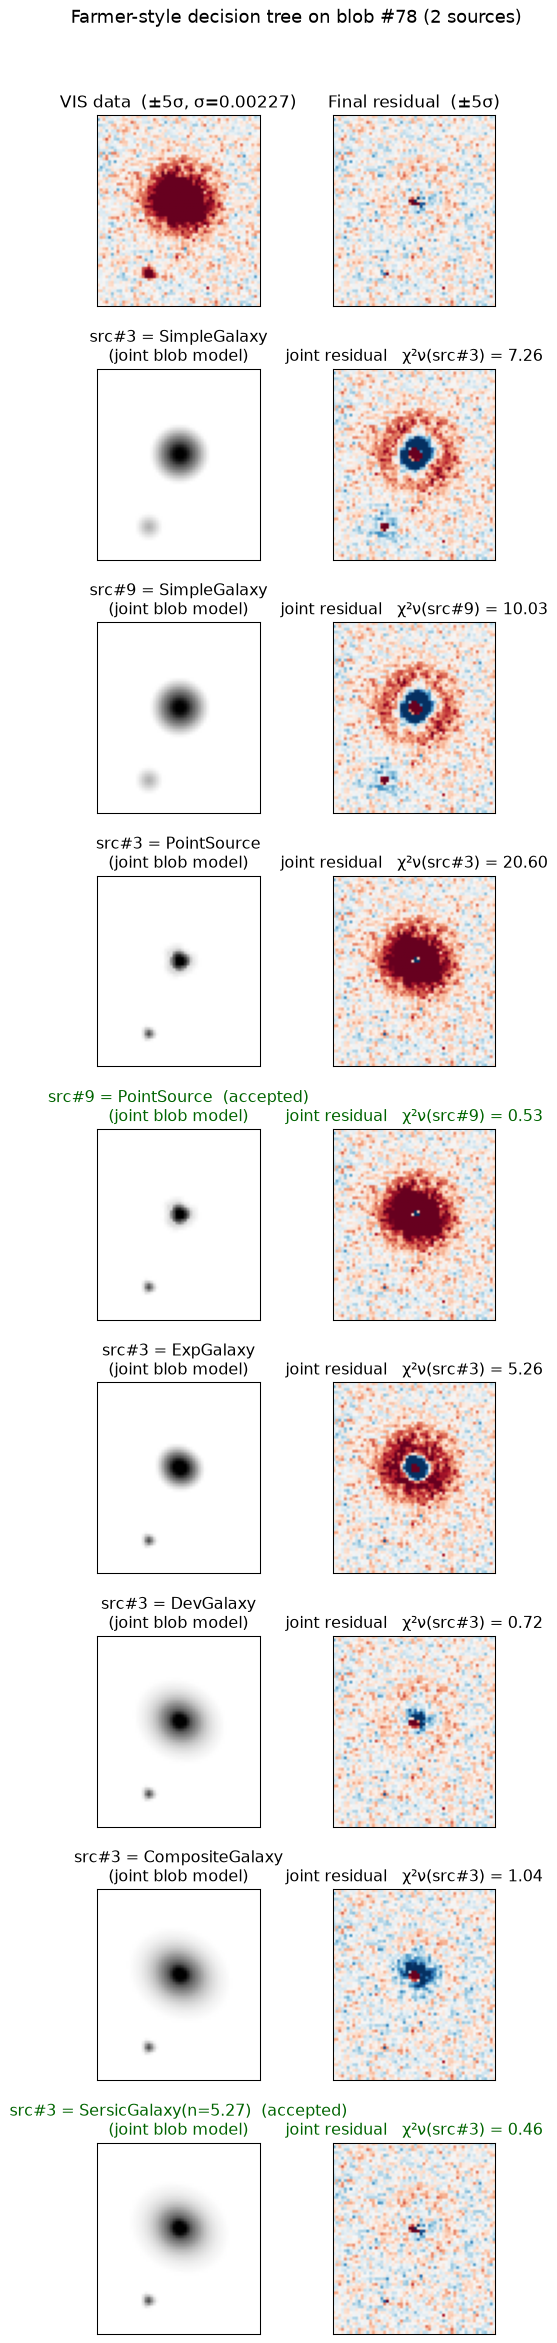

In [8]:
fig, _ = ep.reproduce_figure3(target_blob, history)
plt.show()


## 8. Run the tree over the full cutout


In [9]:
sources_tree, _ = ep.run_model_selection(
    mer_cat, tim_vis, vis.data, tim_vis.getInvvar(),
    pixscale_arcsec=vis.pixel_scale_arcsec,
    n_workers=min(4, os.cpu_count() or 1),
)
print(f"Sources outside detected blobs: {sum(s is None for s in sources_tree)}; "
      "Notebook 01 retains their MER priors.")
print("model-class histogram from the chi-squared tree:")
class_hist = {}
for s in sources_tree:
    if s is None: continue
    class_hist[type(s).__name__] = class_hist.get(type(s).__name__, 0) + 1
for k in sorted(class_hist):
    print(f"  {k:<22s} {class_hist[k]}")


Sources outside detected blobs: 4; Notebook 01 retains their MER priors.
model-class histogram from the chi-squared tree:
  DevGalaxy              9
  ExpGalaxy              29
  FixedCompositeGalaxy   4
  PointSource            13
  SersicGalaxy           4


Change the selected blob in section 5 to inspect another case. Model classes
can depend on signal-to-noise, neighbouring sources, and the allowed profiles;
agreement with a catalog classification is not guaranteed.
